In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_churn.csv")
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [3]:
df.info()
df.describe()
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


Churn
0    447
1     53
Name: count, dtype: int64

In [4]:
df.drop('CustomerID', axis=1, inplace=True)

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['PaperlessBilling'] = le.fit_transform(df['PaperlessBilling'])

In [10]:
print(df.columns)

Index(['Tenure', 'MonthlyCharges', 'TotalCharges', 'PaperlessBilling',
       'SeniorCitizen', 'Churn', 'Contract_Month-to-month',
       'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank Transfer',
       'PaymentMethod_Credit Card', 'PaymentMethod_Electronic Check'],
      dtype='object')


In [13]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
df[['Tenure','MonthlyCharges']] = minmax.fit_transform(df[['Tenure','MonthlyCharges']])

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['TotalCharges']] = scaler.fit_transform(df[['TotalCharges']])

In [15]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['MonthlyCharges'] >= Q1 - 1.5*IQR) & 
        (df['MonthlyCharges'] <= Q3 + 1.5*IQR)]
print(df)

       Tenure  MonthlyCharges  TotalCharges  PaperlessBilling  SeniorCitizen  \
0    0.071429        0.245810     -1.194621                 0              1   
1    0.285714        0.519553     -1.100305                 1              1   
2    0.371429        0.061453     -1.232259                 0              1   
3    0.742857        0.050279      1.289485                 0              1   
4    0.214286        0.921788     -1.423548                 0              1   
..        ...             ...           ...               ...            ...   
495  0.700000        0.603352      1.209781                 1              1   
496  0.014286        0.162011      0.743513                 0              1   
497  0.642857        0.994413     -0.920971                 0              0   
498  0.000000        0.921788      0.671779                 1              1   
499  0.371429        0.899441      0.023963                 0              1   

     Churn  Contract_Month-to-month  Co

In [16]:
from scipy import stats

z = np.abs(stats.zscore(df['TotalCharges']))
df = df[z < 3]

In [17]:
df['AvgCharges'] = df['TotalCharges'] / (df['Tenure'] + 1)

df['TenureGroup'] = df['Tenure'] // 12

df['HighSpender'] = (df['MonthlyCharges'] > 0.5).astype(int)

df['ChargesPerTenure'] = df['TotalCharges'] / (df['Tenure'] + 1)

df['LongTermCustomer'] = (df['Tenure'] > 0.3).astype(int)

df['ValueCustomer'] = (df['TotalCharges'] > 0).astype(int)

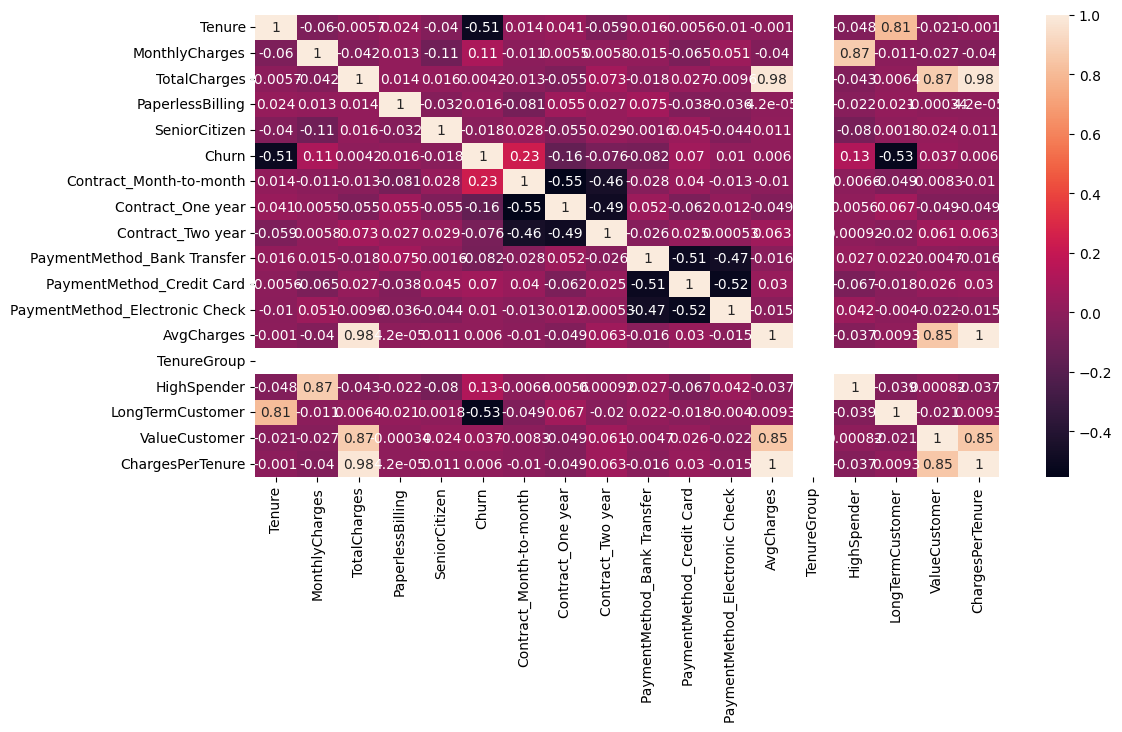

In [18]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Churn', axis=1)
y = df['Churn']

model = RandomForestClassifier()
model.fit(X, y)

print(model.feature_importances_)

[0.4315667  0.05789306 0.05214223 0.0132771  0.0089593  0.06511589
 0.03020037 0.01723926 0.00857101 0.00848007 0.00556554 0.07017119
 0.         0.02084296 0.13156042 0.00571028 0.07270464]


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [21]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.95
